In [1]:
import os
import math
import numpy as np
import xarray as xr
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from graphcast.losses import normalized_latitude_weights

import graphufs
from graphufs.lineplot import LinePlotter

In [2]:
plt.style.use("graphufs.plotstyle")

In [3]:
scratch = "/pscratch/sd/n/nagarwal"
fig_dir = os.path.join(os.getcwd(), "figures")

In [4]:
truths = ["Replay"]
models = [
    "ocn-only R4 T3M graphufs 6h 6hour",
    "ocn-only R5 T1M graphufs 24h 24hour-1IC",
    "ocn-only R6 T1M graphufs 24h 24hour-2IC"
]
apply_latitude_weighting = True

In [5]:
duration = "240h"
sq_error = {}

for model in models:
    model_type, run, expt, pred_prefix, ts, descrip = model.split(" ")
    infer_dir = f"inference_{expt}" if len(expt)!=0 else "inference" 
    location = os.path.join(scratch, model_type, run, f"{infer_dir}/validation/")

    # read model predictions
    fname = f"{location}/{pred_prefix.lower()}.{duration}.zarr"
    model_pred = xr.open_zarr(fname)
    
    # model name for storing data
    model_name = model.replace(" ", "_")
    
    sq_error[model_name] = {}
    
    for truth in truths:
        # reference truth
        fname = f"{location}/{truth.lower()}.{duration}.zarr"
        ref_truth = xr.open_zarr(fname)

        # compute mask
        mask = xr.where(ref_truth.so.isel(time=0, lead_time=0,)==0, 0, 1)
        
        # store errors
        sq_error[model_name][truth] = {}
                    
        for var in model_pred.data_vars:
            if "z_l" in model_pred[var].coords:
                sq_error[model_name][truth][var] = (model_pred[var]*mask - ref_truth[var])**2
            else:
                sq_error[model_name][truth][var] = (model_pred[var]*mask.isel(z_l=0) - ref_truth[var])**2

In [11]:
# units
units = {}
units["SSH"] = "m"
units["so"] = "psu"
units["temp"] = "degC"
units["uo"] = "m/s"
units["vo"] = "m/s"

# error bounds
error_bounds = {}
error_bounds["SSH"] = {"vmin":0, "vmax":0.2}  # 0-15 cm
error_bounds["so"] = {"vmin":0, "vmax":0.4}   # 0-0.4 psu
error_bounds["temp"] = {"vmin":0, "vmax":0.6} # 0-0.5 degC
error_bounds["uo"] = {"vmin":0, "vmax":0.12}  # 0-0.25 m/s
error_bounds["vo"] = {"vmin":0, "vmax":0.12}  # 0-0.25 m/s

In [7]:
vars_2d = ["SSH"]
vars_3d = list(set(model_pred.data_vars) - set(vars_2d))

## Plot 2D

In [8]:
def plot_rmse_vs_leadtime_2d(ax, 
                             da: xr.DataArray, 
                             var_name: str = None, 
                             unit: str = None, 
                             timestep: str = "6h", 
                             forecast_days: int = 10, 
                             label: str = "",
                             vmin: float = None,
                             vmax: float = None,
                             show_title: bool = True):
    """
    Plot RMSE vs lead_time for a 2D variable.

    Parameters:
    - ax: plotting axis
    - da: xarray.DataArray with dimension ("lead_time",)
    - var_name: name of the variable
    - unit: unit of the variable
    - timestep: time step of the forecast (must be in hours)
    - forecast_days: number of days of forecasts
    - label: label to use in legend
    - vmin, vmax: RMSE bounds
    """
    # convert lead time to hours/days
    lead_time_hours = da["lead_time"].values / np.timedelta64(1, "h")
    lead_time_days = lead_time_hours / 24

    # subsample to the end of every day
    steps_per_day = int(24 / int(timestep[:-1])) 
    ts_to_plot = np.arange(steps_per_day-1, len(da), steps_per_day)

    # get values to plot
    values = da.values[ts_to_plot]
    days = lead_time_days[ts_to_plot]

    # vmin/vmax
    vmin = vmin if vmin is not None else error_bounds[var_name]["vmin"]
    vmax = vmax if vmax is not None else error_bounds[var_name]["vmax"]

    # plot
    ax.plot(days, values, linewidth=2, label=label,)
    ax.set_ylim(vmin, vmax)

    # axis labels
    xlabel = f"Forecast Lead Time [days]"
    ylabel = f"RMSE [{unit}]" if unit is not None else f"RMSE [{units[var_name]}]"
    if apply_latitude_weighting:
        ylabel = f"LW-{ylabel}"
    ax.set_xlabel(xlabel, fontsize=14,)
    ax.set_ylabel(ylabel, fontsize=14,)

    # axis ticks
    ax.tick_params(axis="x", labelsize=14,)
    ax.tick_params(axis="y", labelsize=14,)

    # axis grid
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    # title
    if show_title:
        ax.set_title(f"{var_name}", fontsize=16,)
    
    return ax

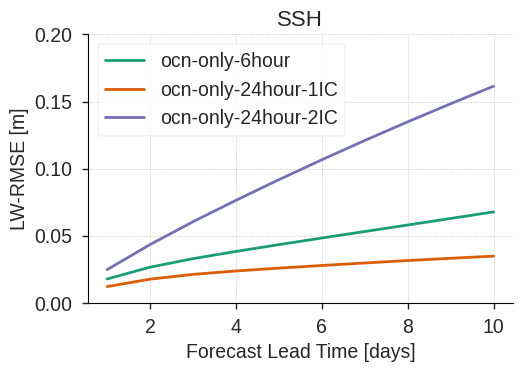

In [16]:
# Plot
n_vars = len(vars_2d)
save_plot = True # remember to change the file name if needed

# Determine grid size for subplots
ncols = 2
nrows = math.ceil(n_vars / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, var_name in enumerate(vars_2d):
    ax = axes[i]
    
    for model in models:
        model_type, run, expt, pred_prefix, ts, descrip = model.split(" ")
        model_name = model.replace(" ", "_")
    
        for truth in truths:       
            sqerr = sq_error[model_name][truth][var_name]
            
            if apply_latitude_weighting:
                weights = normalized_latitude_weights(sqerr)
                sqerr = sqerr * weights.astype(sqerr.dtype)

            # avg over the remaining dims
            dims_to_avg = set(sqerr.dims) - {"lead_time"}
            da = np.sqrt(sqerr.mean(dim=dims_to_avg))

            # plot
            _ = plot_rmse_vs_leadtime_2d(
                ax, 
                da, 
                var_name=var_name, 
                unit=units.get(var_name, ""),
                timestep=ts, 
                forecast_days=10, 
                label=f"{model_type}-{descrip}",
            )

    ax.legend(fontsize=14)
    
# Hide extra axes if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
            
plt.tight_layout()

# save plot
if save_plot:
    figname = f"RMSE_vs_lead_time_SSH_ocn_only_6h_vs_24h_1and2_ICs.jpeg"
    if apply_latitude_weighting:
        figname = f"LW-{figname}"
    plt.savefig(f"./figures/{figname}", dpi=300)
        
plt.show()

## Error as a function of the latitude 

#### Note that no latitude weighting will be applied here to the errors irrespective of the value of the boolean parameter "apply_latitude_weighting", otherwise errors would be latitude independent.

In [13]:
def plot_rmse_vs_latitude(ax, 
                          da: xr.DataArray, 
                          var_name: str = None, 
                          unit: str = None, 
                          timestep: str = "6h", 
                          forecast_days: int = 10, 
                          label: str = "",
                          vmin: float = None,
                          vmax: float = None,
                          days_to_plot:list = (1, 2, 4, 6, 8, 10),
                          cmap = cm.plasma,
                          norm = None, 
                          show_cbar:bool = True,
                          show_title:bool = True,):
    """
    Plot RMSE vs latitudes for specified lead times.

    Parameters:
    - ax: plotting axis
    - da: xarray.DataArray with dimension ("lead_time",)
    - var_name: Name of the variable
    - unit: Unit of the variable
    - timestep: time step of the forecast (must be in hours)
    - forecast_days: number of days of forecasts
    - label: label to use in title
    - vmin, vmax: RMSE bounds
    - days_to_plot: lead times (in days) to plot
    - cmap: colormap
    - norm: normalized colormap
    """

    # check relevant axes
    if not {"lead_time", "lat"}.issubset(set(da.dims)):
        raise ValueError("Expected 'lead_time' and 'z_l' dimensions")
    
    # setup the plot params
    lats = da["lat"].values
    timestep_int = int(timestep[:-1]) # in hours
    colors = [cmap(norm(day)) for day in days_to_plot]
    
    vmin = vmin or error_bounds.get(var_name, {}).get("vmin", None)
    vmax = vmax or error_bounds.get(var_name, {}).get("vmax", None)

    # plot
    for day, color in zip(days_to_plot, colors):
        lt_idx = int(day * 24 / timestep_int) - 1
        rmse = da.isel(lead_time=lt_idx)
        ax.plot(lats, rmse, label=f"{day} day", color=color,)
        

    # axis ticks and labels
    xlabel = f"Latitude"
    ylabel = f"RMSE [{unit}]" if unit is not None else "RMSE"
    ax.set_xlabel(xlabel, fontsize=14,)
    ax.set_ylabel(ylabel, fontsize=14,)
    ax.set_ylim(vmin, vmax)
    ax.tick_params(axis='both', which='major', labelsize=14)

    # axis grid
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    # title
    if show_title:
        ax.set_title(f"{var_name}, {label}", fontsize=16,)

    # colorbar for lead time gradient
    if show_cbar:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cb = plt.colorbar(sm, orientation="vertical", ax=ax, fraction=0.02, pad=0.02,)
        cb.ax.tick_params(labelsize=14)
        cb.set_label(label="Forecast Lead Time [days]", size=14)

    return ax

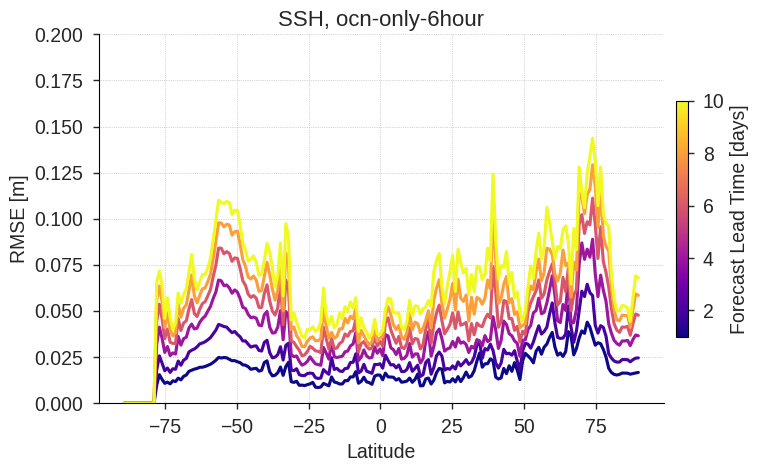

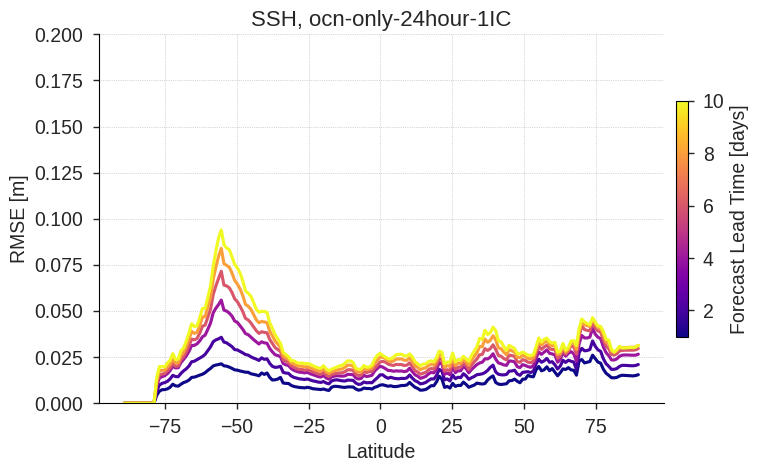

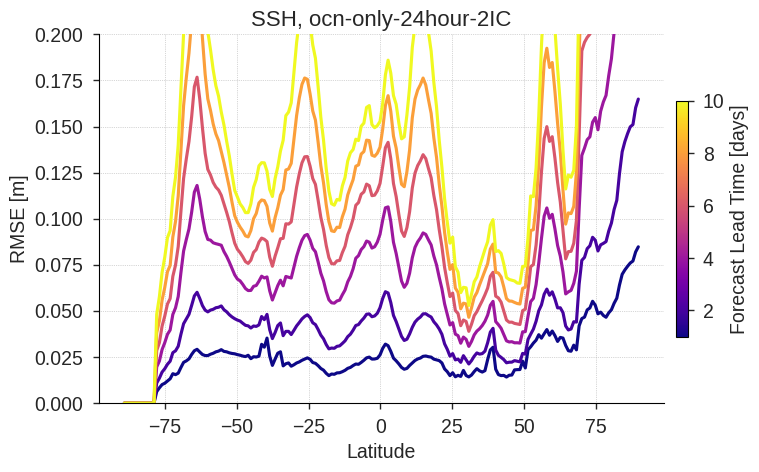

In [17]:
n_vars = len(vars_2d)
ncols = 2
nrows = math.ceil(n_vars / ncols)
save_plot = True

# Lead times for which to plot RMSE lines
days_to_plot = [1, 2, 4, 6, 8, 10]
cmap = cm.plasma
norm = mcolors.Normalize(vmin=min(days_to_plot), vmax=max(days_to_plot))

for model in models:
    model_type, run, expt, pred_prefix, ts, descrip = model.split(" ")
    model_name = model.replace(" ", "_")

    for truth in truths:
        fig, axes = plt.subplots(
            nrows=nrows, ncols=ncols, figsize=(7 * ncols, 5 * nrows), squeeze=False
        )

        for idx, var_name in enumerate(vars_2d):
            ax = axes[idx // ncols][idx % ncols]

            # Compute RMSE, averaged over all non-lead_time/lat dims
            da = sq_error[model_name][truth][var_name]
            dims_to_avg = set(da.dims) - {"lead_time", "lat"}
            da = np.sqrt(da.mean(dim=dims_to_avg))

            _ = plot_rmse_vs_latitude(
                    ax=ax,
                    da=da,
                    var_name=var_name,
                    unit=units.get(var_name),
                    timestep=ts,
                    forecast_days=10,
                    label=f"{model_type}-{descrip}",
                    cmap=cmap,
                    norm=norm,
                    days_to_plot=days_to_plot,
                    
            )

        # Remove any unused axes
        for idx in range(len(vars_2d), nrows * ncols):
            fig.delaxes(axes[idx // ncols][idx % ncols])

        #fig.suptitle(f"RMSE vs Latitude for {model_name} vs {truth}", fontsize=14)
        plt.tight_layout()

        # Save plot
        if save_plot:
            figname = f"RMSE_vs_latitude_SSH_{model_name}.jpeg"
            plt.savefig(f"./figures/{figname}", dpi=300)

        plt.show()

## Plot 3D

In [15]:
def plot_rmse_vs_depth(ax, 
                       da: xr.DataArray, 
                       var_name: str = None, 
                       unit: str = None, 
                       timestep: str = "6h", 
                       forecast_days: int = 10, 
                       label: str = "",
                       vmin: float = None,
                       vmax: float = None,
                       days_to_plot=(1, 2, 4, 6, 8, 10),
                       cmap=cm.plasma,
                       norm=None,
                       show_title: bool = True,
                       show_cbar: bool = True):
    """
    Plot RMSE vs ocean depth for different lead times.

    Parameters:
    - ax: plotting axis
    - da: xarray.DataArray with dimension ("lead_time",)
    - var_name: Name of the variable
    - unit: Unit of the variable
    - timestep: time step of the forecast (must be in hours)
    - forecast_days: number of days of forecasts
    - label: label to use in title
    - vmin, vmax: RMSE bounds
    - days_to_plot: lead times (in days) to plot
    - cmap: colormap
    - norm: normalized colormap
    """

    # check relevant axes
    if not {"lead_time", "z_l"}.issubset(set(da.dims)):
        raise ValueError("Expected 'lead_time' and 'z_l' dimensions")
    
    # setup the plot params
    depths = da["z_l"].values
    timestep_int = int(timestep[:-1])
    colors = [cmap(norm(day)) for day in days_to_plot]
    vmin = vmin if vmin is not None else error_bounds[var_name]["vmin"]
    vmax = vmax if vmax is not None else error_bounds[var_name]["vmax"]

    # plot
    for day, color in zip(days_to_plot, colors):
        lt_idx = int(day*24 / timestep_int) - 1
        rmse = da.isel(lead_time=lt_idx)
        ax.plot(rmse, depths, label=f"{day} day", color=color,)
        

    # axis ticks and labels
    #ax.invert_yaxis()
    xlabel = f"RMSE [{unit}]" if unit is not None else "RMSE"
    if apply_latitude_weighting:
        xlabel = f"LW-{xlabel}"
    ylabel = f"Depth [m]"
    ax.set_xlabel(xlabel, fontsize=14,)
    ax.set_ylabel(ylabel, fontsize=14,)
    ax.set_xlim(vmin, vmax)

    # axis grid
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    # title
    if show_title:
        ax.set_title(f"{var_name}, {label}", fontsize=16,)

    # colorbar
    if show_cbar:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, orientation="vertical", ax=ax,
                            fraction=0.05, pad=0.02,)
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label(label="Forecast Lead Time [days]", size=14)
    
    return ax

var_name: so
var_name: temp
var_name: uo
var_name: vo


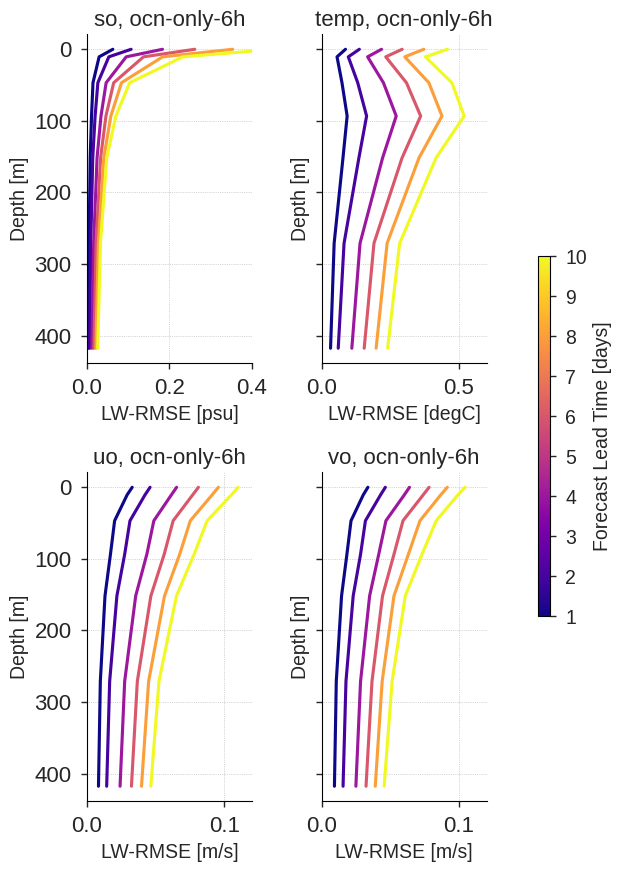

var_name: so
var_name: temp
var_name: uo
var_name: vo


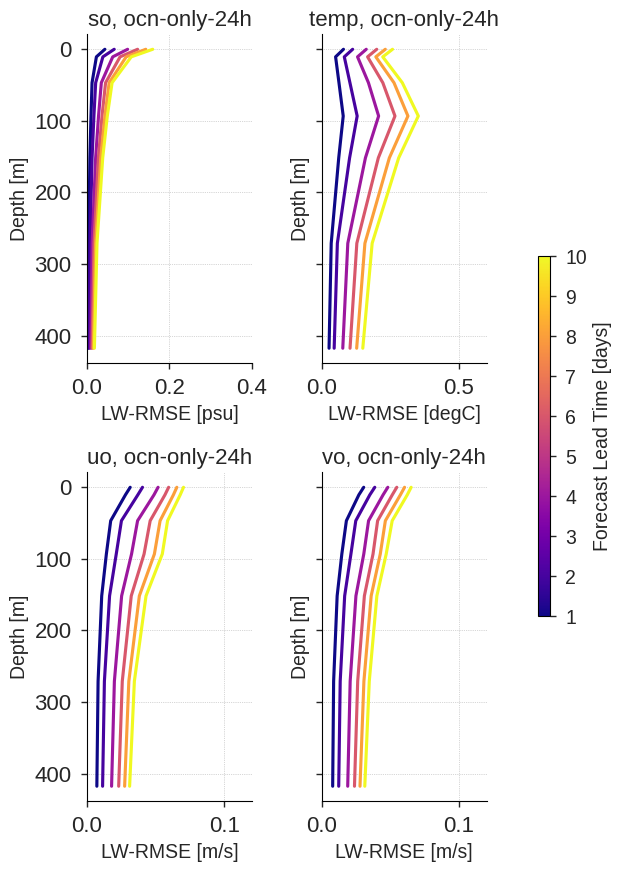

In [20]:
vars_3d.sort()
n_vars = len(vars_3d)
ncols = 2
nrows = math.ceil(n_vars / ncols)
save_plot = True

# Lead times for which to plot RMSE lines
days_to_plot = [1, 2, 4, 6, 8, 10]
cmap = cm.plasma
norm = mcolors.Normalize(vmin=min(days_to_plot), vmax=max(days_to_plot))

for model in models:
    model_type, run, expt, pred_prefix, ts = model.split(" ")
    model_name = model.replace(" ", "_")

    for truth in truths:
        fig, axes = plt.subplots(
            nrows=nrows, ncols=ncols, figsize=(3 * ncols, 4.5 * nrows),
            sharey = "all",
        )

        for idx, var_name in enumerate(vars_3d):
            print("var_name:", var_name)
            ax = axes[idx // ncols][idx % ncols]

            # Compute RMSE, averaged over all non-lead_time/lat dims
            sqerr = sq_error[model_name][truth][var_name]
            if apply_latitude_weighting:
                weights = normalized_latitude_weights(sqerr)
                sqerr = sqerr * weights.astype(sqerr.dtype)
            dims_to_avg = set(sqerr.dims) - {"lead_time", "z_l"}
            da = np.sqrt(sqerr.mean(dim=dims_to_avg))
            ax = plot_rmse_vs_depth(
                    ax=ax,
                    da=da,
                    var_name=var_name,
                    unit=units.get(var_name),
                    timestep=ts,
                    forecast_days=10,
                    label=f"{model_type}-{ts}",
                    days_to_plot=days_to_plot,
                    cmap=cmap,
                    norm=norm,
                    show_cbar=False,
            )
            
        ax.invert_yaxis()
        
        # Remove any unused axes
        for idx in range(len(vars_3d), nrows * ncols):
            fig.delaxes(axes[idx // ncols][idx % ncols])

        plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on right (90% width)
        
        # Add shared colorbar
        cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4]) # [left, bottom, width, height]
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=cbar_ax, label="Forecast Lead Time (days)",
                            orientation="vertical", fraction=0.05, pad=0.02)
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label(label="Forecast Lead Time [days]", size=14)

        # Save plot
        if save_plot:
            figname = f"RMSE_vs_depth_{model_name}.jpeg"
            if apply_latitude_weighting:
                figname = f"LW-{figname}"
            plt.savefig(f"./figures/{figname}", dpi=300)

        plt.show()

## Error as a function of the latitude for selected vertical levels

In [21]:
# update error bounds
error_bounds["so"]["vmax"] = [1, 0.3, 0.2, 0.05]   
error_bounds["temp"]["vmax"] = [1.0, 1.0, 1.0, 0.5] 
error_bounds["uo"]["vmax"] = [0.3, 0.3, 0.3, 0.1]
error_bounds["vo"]["vmax"] = [0.3, 0.2, 0.2, 0.1] 

In [ ]:
vars_3d.sort()
levels = [0, 50, 100, 400]
n_vars = len(vars_3d)
save_plot = True

# Prepare color gradient
days_to_plot = [1, 2, 4, 6, 8, 10]
cmap = cm.plasma
norm = mcolors.Normalize(vmin=min(days_to_plot), vmax=max(days_to_plot))

for model in models:
    model_type, run, expt, pred_prefix, ts = model.split(" ")
    model_name = model.replace(" ", "_")

    for truth in truths:
        fig, axes = plt.subplots(nrows=len(levels), ncols=n_vars,
                                 figsize=(7.5 * n_vars, 5.5 * len(levels)),
                                 squeeze=False)

        for j, var_name in enumerate(vars_3d):
            print("var:", var_name)
            sqerr = sq_error[model_name][truth][var_name]
            dims_to_avg = set(sqerr.dims) - {"lead_time", "z_l", "lat"}
            da = np.sqrt(sqerr.mean(dim=dims_to_avg))

            for i, level in enumerate(levels):
                print("level:", level)
                da_lev = da.sel(z_l=level, method="nearest")
                plot_rmse_vs_latitude(
                    axes[i][j], 
                    da_lev, 
                    var_name=var_name,
                    unit=units.get(var_name),
                    timestep=ts,
                    forecast_days=10, 
                    label=f"{model_type}{ts}",
                    vmax=error_bounds[var_name]["vmax"][i],
                    days_to_plot=days_to_plot,
                    cmap=cmap, 
                    norm=norm, 
                    show_cbar=False,
                )
                if j==0:
                    axes[i][j].set_ylabel(f"z_l={da_lev.z_l.values:.2f}m", size=12)

        # Add shared colorbar
        fig.subplots_adjust(right=0.85)
        cbar_ax = fig.add_axes([0.9, 0.15, 0.01, 0.7]) # [left, bottom, width, height]
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        fig.colorbar(sm, cax=cbar_ax, label="Forecast Lead Time [days]",
                     orientation="vertical", fraction=0.05, pad=0.02)

        fig.suptitle(f"RMSE vs Latitude for {model_name} vs {truth}", fontsize=14)

        #plt.tight_layout()
        if save_plot:
            fname = f"./figures/RMSE_vs_latitude_{model_name}.jpeg"
            plt.savefig(fname, dpi=300)
        plt.show()

var: so
level: 0
Error in callback <function _draw_all_if_interactive at 0x7f614d92db20> (for post_execute), with arguments args (),kwargs {}:


#### Separate figure for each variable. Each figure would contain columns corresponding to the model compared and the rows would correspond to the levels.

var: so
level: 0
level: 50
level: 100
level: 400
level: 0
level: 50
level: 100
level: 400


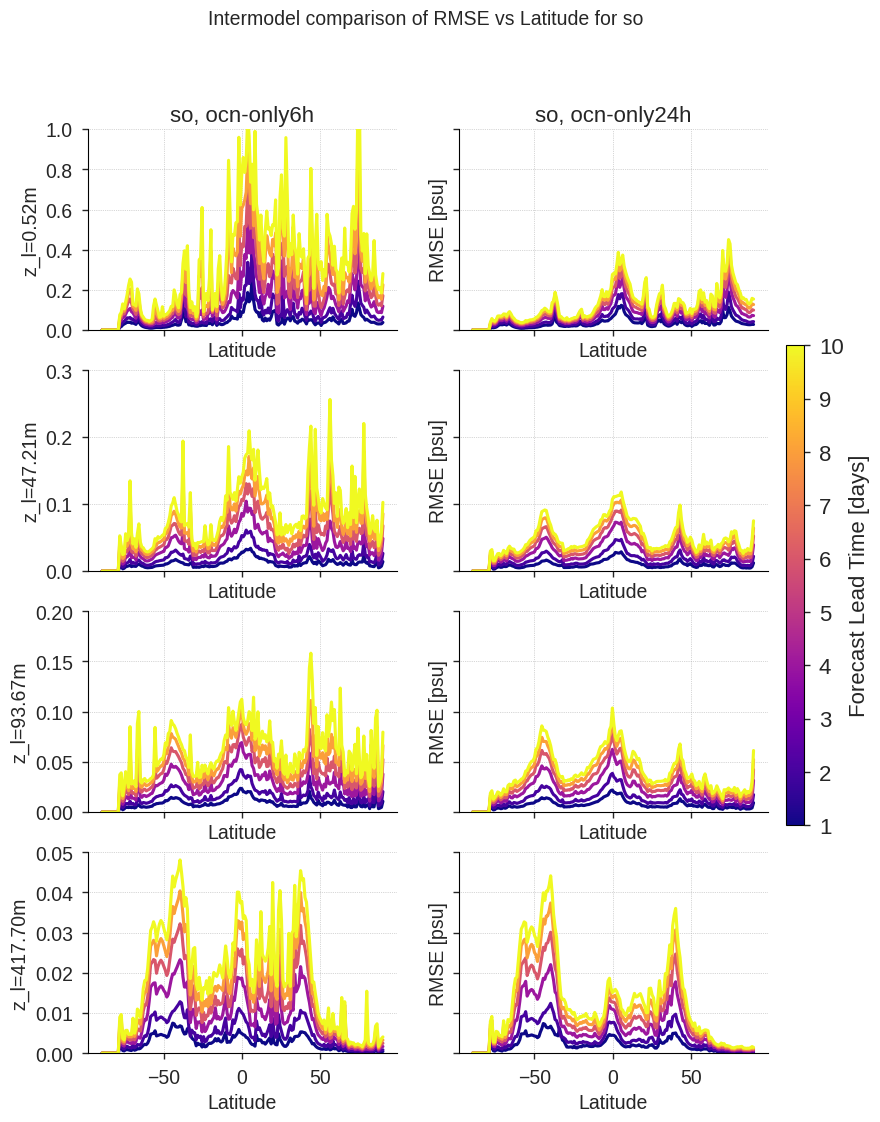

var: temp
level: 0
level: 50
level: 100
level: 400
level: 0
level: 50
level: 100
level: 400


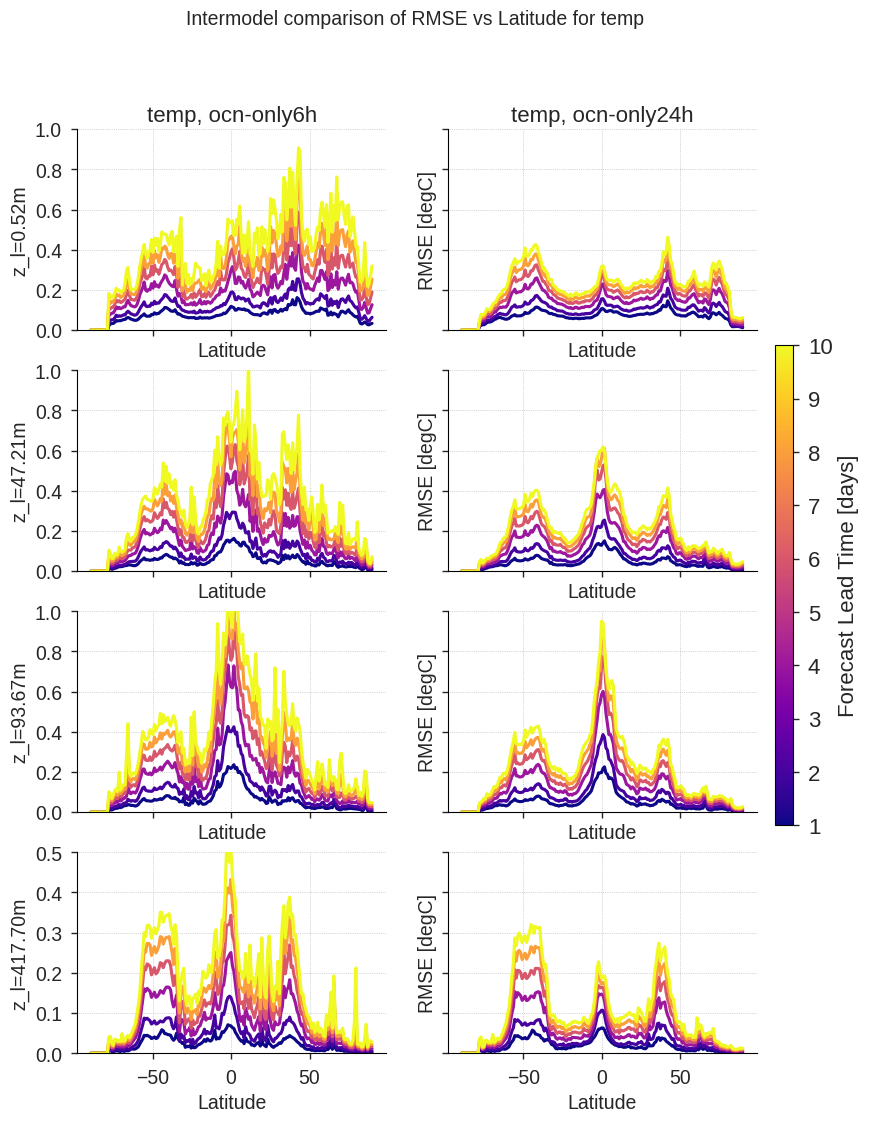

var: uo
level: 0
level: 50
level: 100
level: 400
level: 0
level: 50
level: 100
level: 400


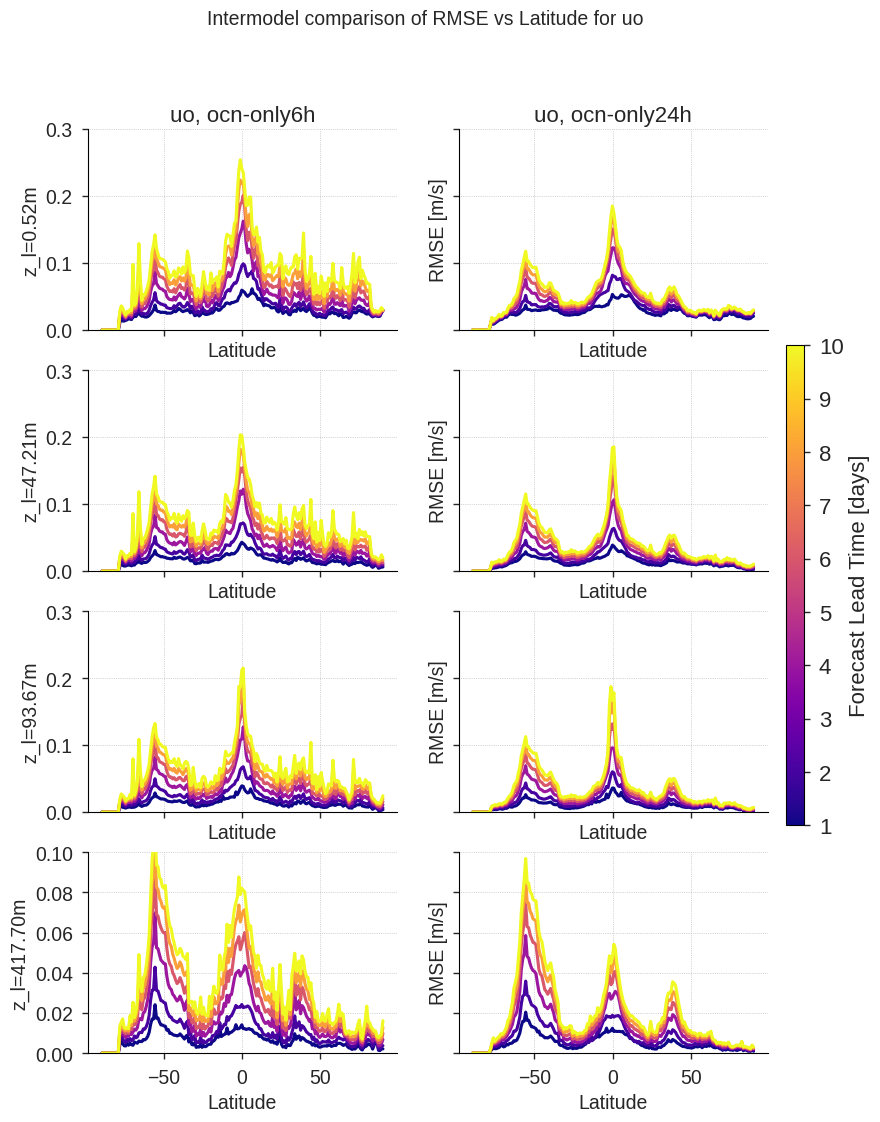

var: vo
level: 0
level: 50
level: 100
level: 400
level: 0
level: 50
level: 100
level: 400


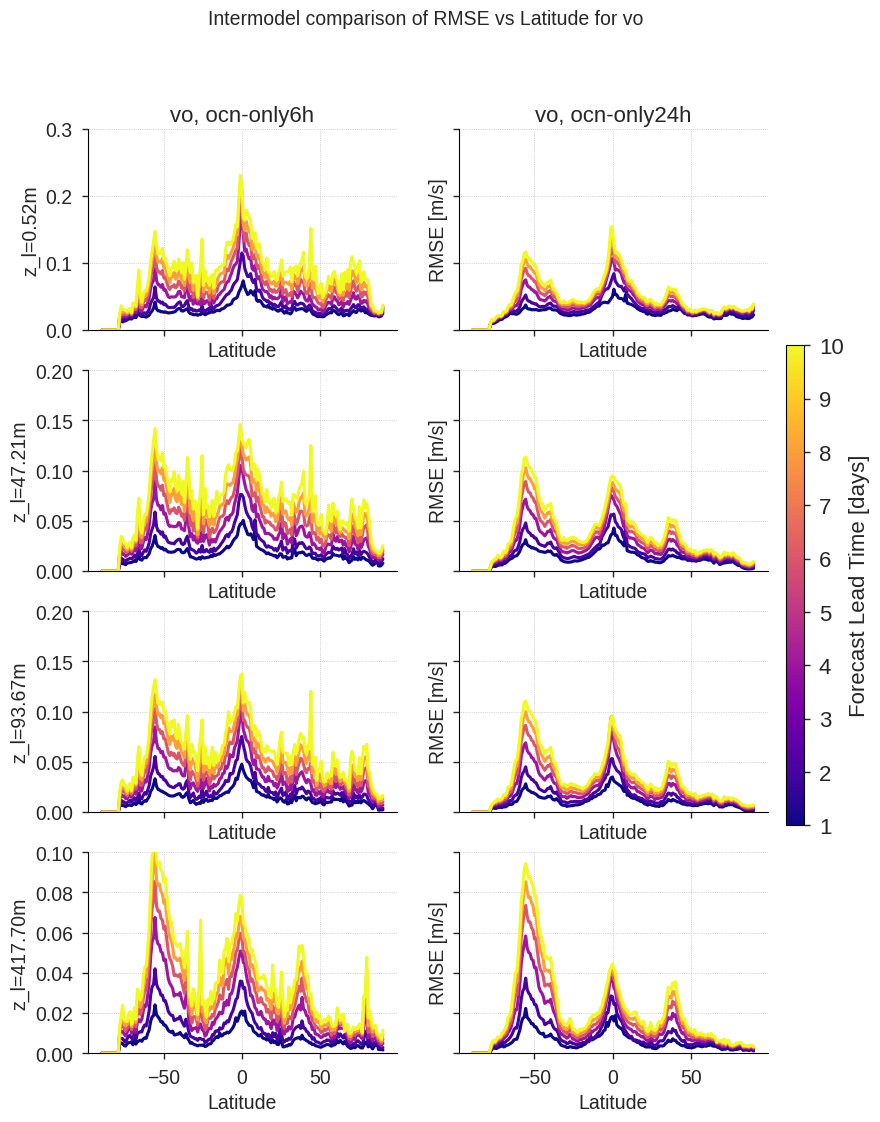

In [23]:
vars_3d.sort()
levels = [0, 50, 100, 400]
n_vars = len(vars_3d)
save_plot = True

# Prepare color gradient
days_to_plot = [1, 2, 4, 6, 8, 10]
cmap = cm.plasma
norm = mcolors.Normalize(vmin=min(days_to_plot), vmax=max(days_to_plot))

for truth in truths:

    for var_name in vars_3d:
        fig, axes = plt.subplots(nrows=len(levels), ncols=len(models),
                                 figsize=(4.5 * len(models), 3 * len(levels)),
                                 sharey="row", sharex="all", squeeze=False)
        print("var:", var_name)

        for j, model in enumerate(models):
            model_type, run, expt, pred_prefix, ts = model.split(" ")
            model_name = model.replace(" ", "_")
            sqerr = sq_error[model_name][truth][var_name]
            dims_to_avg = set(sqerr.dims) - {"lead_time", "z_l", "lat"}
            da = np.sqrt(sqerr.mean(dim=dims_to_avg))

            for i, level in enumerate(levels):
                print("level:", level)
                da_lev = da.sel(z_l=level, method="nearest")
                plot_rmse_vs_latitude(
                    axes[i][j], 
                    da_lev, 
                    var_name=var_name,
                    unit=units.get(var_name),
                    timestep=ts,
                    forecast_days=10, 
                    label=f"{model_type}{ts}",
                    vmax=error_bounds[var_name]["vmax"][i],
                    days_to_plot=days_to_plot,
                    cmap=cmap, 
                    norm=norm, 
                    show_cbar=False,
                    show_title=True if i == 0 else False,
                )
                if j == 0:
                    axes[i][j].set_ylabel(f"z_l={da_lev.z_l.values:.2f}m",)

        # Add shared colorbar
        fig.subplots_adjust(right=0.88)
        cbar_ax = fig.add_axes([0.9, 0.3, 0.02, 0.4]) # [left, bottom, width, height]
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        fig.colorbar(sm, cax=cbar_ax, label="Forecast Lead Time [days]",
                     orientation="vertical", fraction=0.05, pad=0.02)

        fig.suptitle(f"Intermodel comparison of RMSE vs Latitude for {var_name}", fontsize=14)

        #plt.tight_layout()
        if save_plot:
            fname = f"./figures/RMSE_vs_latitude_{var_name}_ocn_only_6h_vs_24h.jpeg"
            plt.savefig(fname, dpi=300)
        plt.show()